In [105]:
import numpy as np
import matplotlib.pyplot as plt

**Generate Equation of a Line**

In [106]:
def generate_linear_data(x_values, num_points, w1, w0, noise_mean, noise_std):

    # Step 1 — Generate random noise from a normal distribution
    noise = np.random.normal(noise_mean, noise_std, num_points)

    # Step 2 — Apply linear equation y = mx + c
    # Then add noise to simulate real-world imperfect data
    y_values = w1 * x_values + w0 + noise

    # Step 3 — Return generated y values
    return y_values

**Dot Prod**

In [107]:
def dot_prod(c0, c1, x, c2, y):
    # Create weights array
    # c0 → bias weight
    # c1 → weight for x
    # c2 → weight for y
    a = np.array([c0, c1, c2])
    
    # Create input vector for one data point
    # 1 → bias term
    # x, y → feature values
    b = np.array([1, x, y])
    
    # Compute dot product (weighted sum)
    # = c0*1 + c1*x + c2*y
    c = np.dot(a, b)
    
    # Return result rounded to 2 decimal places
    return round(c, 2)

**Asserts**

In [108]:
assert dot_prod(-1, 2, 1, 1, 0.5) == 1.5

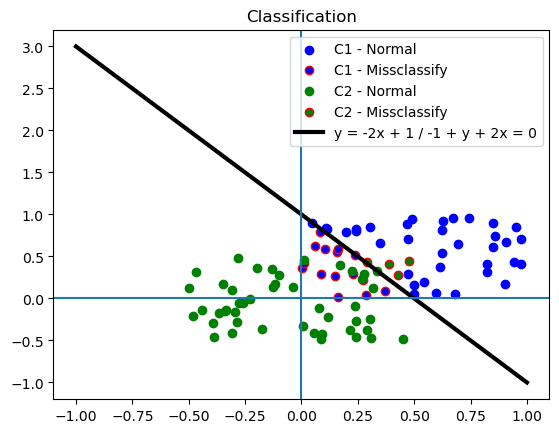

In [113]:
n = 50  # number of data points

# Lists to store misclassified and correctly classified points for class 1
x1_missclassify_points = []
y1_missclassify_points = []
x1_normal_points = []
y1_normal_points = []

# Lists to store misclassified and correctly classified points for class 2
x3_missclassify_points = []
y3_missclassify_points = []
x3_normal_points = []
y3_normal_points = []

# Generate random data for class 1 (uniform between 0 and 1)
x1 = np.random.random(n)
y1 = np.random.random(n)

# Generate random data for class 2 (uniform between -0.5 and 0.5)
x3 = np.random.uniform(0.5, -0.5, n)
y3 = np.random.uniform(0.5, -0.5, n)

# Create x values for decision boundary line
x0 = np.linspace(-1, 1, n)

# Generate corresponding y values for the line (y = -2x + 1)
y0 = generate_linear_data(x0, n, -2, 1, 0, 0)

# Loop through each point
for i in range(n):

    # Check classification for class 1 points
    # If dot product < 0 → misclassified
    if (dot_prod(-1, 2, x1[i], 1, y1[i])) < 0:
        x1_missclassify_points.append(x1[i])
        y1_missclassify_points.append(y1[i])
    else:
        # Correctly classified
        x1_normal_points.append(x1[i])
        y1_normal_points.append(y1[i])

    # Check classification for class 2 points
    # If dot product > 0 → misclassified
    if (dot_prod(-1, 2, x3[i], 1, y3[i])) > 0:
        x3_missclassify_points.append(x3[i])
        y3_missclassify_points.append(y3[i])
    else:
        # Correctly classified
        x3_normal_points.append(x3[i])
        y3_normal_points.append(y3[i])

# Plot correctly classified class 1 points (blue)
plt.scatter(x1_normal_points, y1_normal_points, color='blue', label='C1 - Normal')

# Plot misclassified class 1 points (blue with red border)
plt.scatter(x1_missclassify_points, y1_missclassify_points,
            facecolors='blue', edgecolors='red', label='C1 - Missclassify')

# Plot correctly classified class 2 points (green)
plt.scatter(x3_normal_points, y3_normal_points, color='green', label='C2 - Normal')

# Plot misclassified class 2 points (green with red border)
plt.scatter(x3_missclassify_points, y3_missclassify_points,
            facecolors='green', edgecolors='red', label='C2 - Missclassify')

# Plot decision boundary line
plt.plot(x0, y0, color='black',
         label='y = -2x + 1 / -1 + y + 2x = 0',
         linewidth=3)

# Draw X and Y axes
plt.axhline(0)
plt.axvline(0)

# Add title and legend
plt.title("Classification")
plt.legend()

# Show plot
plt.show()